IPYNB notebook to preprocess data imported from matlab, and convert it into the format accepted by the input

plotting the experimental data

In [1]:
import scipy.io
import pandas as pd
import matplotlib as plt
import numpy as np
from matplotlib import pyplot
from matplotlib import markers

m: 9.173748612729123e-26
hbar: 1.0545718176461565e-34
kb: 1.380649e-23
tD: 753.1888376153266
d_1: 0.537451510651458
exp_fact: 0.0008115092576829611


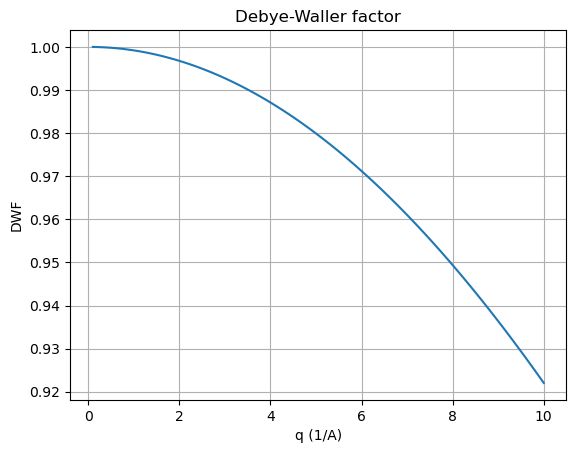

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import math
import xrayutilities as xu

crystal = xu.materials.Crystal.fromCIF('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/C3/PBCO_1_3_C3.cif')
m = 0.0
im = 0
for a, _, _, b in crystal.lattice.base():
    m += a.weight
    im += 1
m = m / float(im)

print(f"m: {m}")


def Debye1(x):
    """
    function to calculate the first Debye function [1]_ as needed
    for the calculation of the thermal Debye-Waller-factor
    by numerical integration

    .. math:: D_1(x) = (1/x) \int_0^x t/(\exp(t)-1) dt

    Parameters
    ----------
    x : float
        argument of the Debye function

    Returns
    -------
    float
        D1(x)  float value of the Debye function

    References
    ----------
    .. [1] http://en.wikipedia.org/wiki/Debye_function
     """

    def __int_kernel(t):
        """
        integration kernel for the numeric integration
        """
        y = t / (np.exp(t) - 1)
        return y

    if x > 0.:
        integral = scipy.integrate.quad(__int_kernel, 0, x)
        d1 = (1 / float(x)) * integral[0]
    else:
        integral = (0, 0)
        d1 = 1.

    return d1


temp = 300  # Kelvin
# W(q) = 3/2* hbar^2*q^2/(m*kB*tD) * (D1(tD/T)/(tD/T) + 1/4)
# DWF = exp(-W(q)) consistent with Vaclav H. and several books
hbar = scipy.constants.hbar
kb = scipy.constants.Boltzmann
print(f"hbar: {hbar}")
print(f"kb: {kb}")
angs = 1.0e-10
cell_length_a = 3.82030 #34.38270
cell_length_b = 3.88548  # 311.68350 * 3
cell_length_c = 11.6835 # 34.96932
volume = cell_length_a * cell_length_b * cell_length_c
volume = volume * (angs ** 3)  # m^3
n_atoms = 13 # 3159
sound_v = 6000  # m/s
tD = (hbar * sound_v)/kb * ((6*n_atoms*np.pi**2)/volume) ** (1 / 3)  # Debye temperature
print(f"tD: {tD}")

d_1 = Debye1(tD / temp)
print(f"d_1: {d_1}")
x = tD / temp
exp_fact = 3 / 2. * hbar ** 2 * 1.0e20 / (m * kb * tD) * (Debye1(x) / x + 0.25)
print(f"exp_fact: {exp_fact}")
example_qs = np.linspace(0.1, 10, 100)
dwf = np.exp(-exp_fact * example_qs ** 2)
plt.plot(example_qs, dwf)
plt.xlabel('q (1/A)')
plt.ylabel('DWF')
plt.title('Debye-Waller factor')
plt.grid()
plt.savefig('debye_waller.png')


In [2]:
structure_type = 'C3'
structure_name = 'PBCO_1_3_' + structure_type

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/'+ structure_name + '.cif'
path_coords = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_coords.txt'


Find where to add the shifts in the list of atom coordinates. 

add the atom displacement distortions

1. check the cif file, section `_iso_parent-to-child.transform_Pp_abc` ( very end of the cif file), change the transformation accordingly in `functions`

# Print all the atom coords

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import math
import xrayutilities as xu

crystal = xu.materials.Crystal.fromCIF(path)
with open(path_coords, 'w') as f:
    for a, n, c, d in crystal.lattice.base():
        #remove commas and replace (number) with 'number' for n[0]
        a = str(a).replace('(', "'").replace(')', "'")
        f.write(f"{a} {n[0]} {n[1]} {n[2]}\n")


WARNING: if the atomic number of an element is less than 10, go into the coords file and tidy the atomic number
example: change ' 8' to '8'.

# The following code adds the atomic displacement variables. 

Things to do beforehand:
1. create `PrNiO2_C4_atom_site_fract_symmform.txt` by running the first code block below.
2. Go to `PrNiO2_C4.cif` (generated from isodistort), find `_atom_site_fract_symmform`
3. copy the info in `_atom_site_fract_symmform` to a new file called `PrNiO2_C4_atom_site_fract_symmform.txt`
4. In `PrNiO2_C4_atom_site_fract_symmform.txt`:

3.1 replace commas with a single space

3.2 replace double space with single space

Output:
`PrNiO2_C4_coords_processed.txt` and `PrNiO2_C4_shift_names.txt`

1. in `PrNiO2_C4_coords_processed.txt` , remove all "
2. remove the comma in the last line
3. copy all into `functions`, and into `atom_position_list`

1. in `PrNiO2_C4_shift_names.txt` , copy to variables list in `atom_position_list`

In [10]:
path_distortions = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_atom_site_fract_symmform.txt'

#create file if it doesn't exist
with open(path_distortions, 'w') as f:
    pass

In [15]:
#load a text file into a dataframe
path_processed_coords = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_coords_processed.txt'
path_shift_names = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_shift_names.txt'

PBCO_coords = pd.read_csv(path_coords, delim_whitespace=True, header=None)
PBCO_distortions = pd.read_csv(path_distortions , delim_whitespace=True, header=None)


#load PBCO_distortions into a list of lists
PBCO_distortions = PBCO_distortions.values.tolist()
PBCO_coords = PBCO_coords.values.tolist()

#create a new column in PBCO_distortions, which adds the second column up cumulatively
PBCO_distortions = pd.DataFrame(PBCO_distortions)
PBCO_coords = pd.DataFrame(PBCO_coords)

# print(PBCO_coords)
# print(PBCO_distortions)

PBCO_coords[2] = PBCO_coords[2].astype(str)
PBCO_coords[3] = PBCO_coords[3].astype(str)
PBCO_coords[4] = PBCO_coords[4].astype(str)


PBCO_distortions[11] = PBCO_distortions[2].cumsum()

#create a list to store all the names of shift name variables
shift_names = []

for i in range(len(PBCO_distortions)):
    #take the ith and ith + 1 element in the last column, and load them into a variable called num_atom_start and num_atom_end. if i is 1 , then num_atom_start must equal to 1, and num_atom_end must equal to the first element in the last column
    if i == 0:
        num_atom_start = 0
        num_atom_end = PBCO_distortions.iloc[i, -1]
    else:
        num_atom_start = PBCO_distortions.iloc[i, -1] - PBCO_distortions.iloc[i, 2]
        num_atom_end = PBCO_distortions.iloc[i, -1]
    
    #check if there are Dx , Dy , Dz in the 3rd , 4th and 5th columns of PBCO_distortions
    if 'Dx' in PBCO_distortions.iloc[i, 8]:
        #string the char in the first column ith row to 'Dx'
        dx_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dx_shift_name = 0
    if 'Dy' in PBCO_distortions.iloc[i, 9]:
        #string the char in the first column ith row to 'Dy'
        dy_shift_name = PBCO_distortions.iloc[i, 0] + '_dy'
    elif 'Dx' in PBCO_distortions.iloc[i, 9]:
        #string the char in the first column ith row to 'Dy'
        dy_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dy_shift_name = 0
    if 'Dz' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first coumn ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dz' 
    elif 'Dy' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first column ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dy'
    elif 'Dx' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first column ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dz_shift_name = 0



    if dx_shift_name != 0:
        shift_names.append(dx_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 2] = str(PBCO_coords.iloc[j, 2] + ' + ') + dx_shift_name
    if dy_shift_name != 0:
        shift_names.append(dy_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 3] = str(PBCO_coords.iloc[j, 3] + ' + ') + dy_shift_name
    if dz_shift_name != 0:
        shift_names.append(dz_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 4] = str(PBCO_coords.iloc[j, 4] + ' + ') + dz_shift_name


for k in range(len(PBCO_coords)):
    PBCO_coords.iloc[k, 0] = str("['" + PBCO_coords.iloc[k, 0] + "'")
    PBCO_coords.iloc[k, 2] = str('[' + PBCO_coords.iloc[k, 2])
    PBCO_coords.iloc[k, 4] = str(PBCO_coords.iloc[k, 4] + "]],")

print(PBCO_coords)
with open(path_processed_coords, 'w') as f:
    for i in range(len(PBCO_coords)):
        f.write(f"{PBCO_coords.iloc[i, 0]}, {PBCO_coords.iloc[i, 1]}, {PBCO_coords.iloc[i, 2]}, {PBCO_coords.iloc[i, 3]}, {PBCO_coords.iloc[i, 4]}\n")
#save PBCO_coords to a csv file
# PBCO_coords.to_csv(path_processed_coords, index=False, header=False)


print(shift_names)
# Convert shift_names to a DataFrame
shift_names = pd.DataFrame(shift_names)
#print all shift_names into a single line
shift_names_txt = shift_names[0].str.cat(sep=', ')
print(shift_names)
# Save shift_names to a text file
with open(path_shift_names, 'w') as f:
    f.write(shift_names_txt)


         0     1                    2                 3                      4
0    ['Pr'  '59'  [0.16667 + Pr1_1_dx               0.5  0.16667 + Pr1_1_dz]],
1    ['Pr'  '59'  [0.83333 + Pr1_1_dx               0.5  0.16667 + Pr1_1_dz]],
2    ['Pr'  '59'  [0.16667 + Pr1_2_dx               0.5      0.5 + Pr1_2_dz]],
3    ['Pr'  '59'  [0.83333 + Pr1_2_dx               0.5      0.5 + Pr1_2_dz]],
4    ['Pr'  '59'  [0.16667 + Pr1_3_dx               0.5  0.83333 + Pr1_3_dz]],
..     ...   ...                  ...               ...                    ...
112   ['O'   '8'   [0.66667 + O4_5_dx  0.1584 + O4_5_dy   0.33333 + O4_5_dz]],
113   ['O'   '8'   [0.33333 + O4_6_dx  0.1584 + O4_6_dy   0.66667 + O4_6_dz]],
114   ['O'   '8'   [0.66667 + O4_6_dx  0.8416 + O4_6_dy   0.66667 + O4_6_dz]],
115   ['O'   '8'   [0.33333 + O4_6_dx  0.8416 + O4_6_dy   0.66667 + O4_6_dz]],
116   ['O'   '8'   [0.66667 + O4_6_dx  0.1584 + O4_6_dy   0.66667 + O4_6_dz]],

[117 rows x 5 columns]
['Pr1_1_dx', 'Pr1_1_dz', 'Pr

C:\Users\User\AppData\Local\Temp\ipykernel_15248\1076584466.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  PBCO_coords = pd.read_csv(path_coords, delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_15248\1076584466.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  PBCO_distortions = pd.read_csv(path_distortions , delim_whitespace=True, header=None)


# the following code is only applicable if the parameters are the atomic displacements. to fit the modes directly, skip to the next section

Preprocess get mode amplitudes

In [ ]:
mode_names = pd.read_csv('raw_data/displacivemode_names.txt' , delim_whitespace=True, header=None)
mode_matrix = pd.read_csv('raw_data/mode_matrix.txt' , delim_whitespace=True, header=None)

#CONVERT TO A LIST OF LISTS
mode_names = mode_names.values.tolist()

# Convert mode_names to a DataFrame
mode_names = pd.DataFrame(mode_names)

num_modes = len(mode_names) 
print(num_modes)

mode_name1 = []
# rewrite the mode names into a new list with the first column as the mode name 
for i in range(num_modes):
    mode_name1.append(str('"' + str(mode_names.iloc[i, 1]) + '"' + ': '))

print(mode_name1)


445
['"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,2/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,4/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[4/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,4/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,4/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '

C:\Users\User\AppData\Local\Temp\ipykernel_25560\395762485.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv('raw_data/displacivemode_names.txt' , delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_25560\395762485.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_matrix = pd.read_csv('raw_data/mode_matrix.txt' , delim_whitespace=True, header=None)


In [168]:
#make a zeros array with len(shift_names) rows and columns
mode_np_matrix = np.zeros((num_modes, num_modes))

print(mode_np_matrix.shape)
print(mode_np_matrix)

#load the third column values from mode_matrix into mode_np_matrix.first column of ith row is the row number of the matrix, second column is the column number of the matrix, third column is the value of the matrix
for i in range(len(mode_matrix)):
    row = mode_matrix.iloc[i, 0] - 1
    col = mode_matrix.iloc[i, 1] - 1
    value = mode_matrix.iloc[i, 2]
    mode_np_matrix[row, col] = value

print(mode_np_matrix)


print(mode_name1)


for row in range(num_modes):
    for col in range(num_modes):
        if mode_np_matrix[row, col] != 0:
            shift_name = shift_names.iloc[col,0]
            
            if mode_np_matrix[row, col] < 0:
                matrix_element = mode_np_matrix[row, col] * -1
                string_mode_np_matrix = str(matrix_element)
                dependent = ' - ' + string_mode_np_matrix + ' * ' + shift_name
            else:
                string_mode_np_matrix = str(mode_np_matrix[row, col])
                dependent = ' + ' + string_mode_np_matrix + ' * ' + shift_name
            
            mode_name1[row] = str(mode_name1[row]) + dependent
        else:
            mode_name1[row] = str(mode_name1[row])



# Save mode_names to a text file without using pandas
with open('raw_data/mode_names_processed.txt', 'w') as f:
    for name in mode_name1:
        f.write(name + ',' + '\n')


'''mode_names_txt = pd.DataFrame(mode_name1)
mode_names_txt.to_csv('raw_data/mode_names_processed.txt', index=False, header=False)

'''


(445, 445)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[-0.32635  0.       0.      ...  0.       0.       0.     ]
 [ 0.       0.32635  0.3473  ...  0.       0.       0.     ]
 [-0.17365  0.       0.      ...  0.       0.       0.     ]
 ...
 [ 0.       0.       0.      ...  0.       0.      -0.17365]
 [ 0.       0.       0.      ...  0.03015  0.       0.     ]
 [ 0.       0.       0.      ...  0.      -0.17365  0.     ]]
['"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,2/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,4/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[4/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h

"mode_names_txt = pd.DataFrame(mode_name1)\nmode_names_txt.to_csv('raw_data/mode_names_processed.txt', index=False, header=False)\n\n"

# This is the next section. fit the mode amplitudes directly
Things to do beforehand:
1. create txt file `PrNiO2_C4_mode_amp_bounds.txt`
2. from `PrNiO2_C4.str` file, at mode definitions, copy all mode names and their info
3. run the file

the code should generate 2 files: `PrNiO2_C4_mode_names_variable` , `PrNiO2_C4_max_bound_vectors`

`PrNiO2_C4_mode_names_variable.txt`: copy this into `shift_atoms_copy` located at the end of the file.

`PrNiO2_C4_max_bound_vectors.txt`: remove the last comma, and load this file in the `gradient_descent.ipynb`




In [5]:
#create a text file to store the mode amplitude bounds
path_mode_amplitudes = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_mode_amp_bounds.txt'
with open(path_mode_amplitudes, 'w') as f:
    pass

In [6]:
path_mode_name_var = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_mode_names_variable.txt'
path_max_bound_vectors = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_max_bound_vectors.txt'

mode_amp_bounds = pd.read_csv(path_mode_amplitudes , delim_whitespace=True, header=None)
print(mode_amp_bounds)
max_bound_vectors   = mode_amp_bounds.iloc[:, 6].values.tolist()


mode_names_variable = mode_amp_bounds.iloc[:, 1].values.tolist()

#remove '!' from all elements in mode_names
mode_names_variable = [name.replace('!', '') for name in mode_names_variable]

with open(path_mode_name_var, 'w') as f:
    for name in mode_names_variable:
        f.write(name + ',')

with open(path_max_bound_vectors, 'w') as f:
    for vector in max_bound_vectors:
        f.write(str(vector) + ',')


       0      1    2    3     4    5     6  \
0    prm    !a1  0.0  min -1.73  max  1.73   
1    prm    !a2  0.0  min -2.00  max  2.00   
2    prm    !a3  0.0  min -1.73  max  1.73   
3    prm    !a4  0.0  min -1.50  max  1.50   
4    prm    !a5  0.0  min -3.00  max  3.00   
..   ...    ...  ...  ...   ...  ...   ...   
97   prm   !a98  0.0  min -3.46  max  3.46   
98   prm   !a99  0.0  min -3.00  max  3.00   
99   prm  !a100  0.0  min -3.00  max  3.00   
100  prm  !a101  0.0  min -3.46  max  3.46   
101  prm  !a102  0.0  min -3.00  max  3.00   

                                           7       8  
0    'Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]  B3u(a)  
1    'Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]  B3u(b)  
2    'Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]  B2u(a)  
3    'Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]  B2u(b)  
4             'Pmmm[0,0,0]GM4-(a)[Pr1:h:dsp]  B2u(a)  
..                                       ...     ...  
97          'Pmmm[0,1/3,0]DT1(a,b)[O4:q:dsp]   B2(a)  
98     

C:\Users\User\AppData\Local\Temp\ipykernel_33128\3680528981.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_amp_bounds = pd.read_csv(path_mode_amplitudes , delim_whitespace=True, header=None)


# displacive mode names
1. create `displacive_modes.txt` file
2. from cif file, copy `_iso_displacivemode_value`

In [3]:
path_displacive_modes = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_displacive_modes.txt'
with open(path_displacive_modes, 'w') as f:
    pass

# construct a matrix which describes the atom shifts caused by the distortion modes

1. go to `PrNiO2_C4.str`
2. find `mode-amplitude to delta transformation`, copy to `delta_transform` file
3. remove `;:  0.00000` 
4. remove everything in front and including the = sign in each line
5. run code
6. remove all `'` from the file.
7. remove last comma
8. copy to `shift_atoms_copy` below
9. copy `mode_name_variable` to `shift_atoms_copy`
10. print matrix

In [18]:
path_delta_transform = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_delta_transform.txt'
with open(path_delta_transform, 'w') as f:
    pass

In [19]:
path_delta_transform_processed = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_delta_transform_processed.txt'

delta_transform = pd.read_csv(path_delta_transform ,header=None)
delta_transform = pd.DataFrame(delta_transform)

wanted_modes = pd.read_csv(path_mode_name_var, header=None)
wanted_modes = wanted_modes.values.flatten().tolist()
for i in range(len(wanted_modes)):
    wanted_modes[i] = str(wanted_modes[i])

# Convert delta_transform to a list of lists
delta_transform = delta_transform.values.tolist()
#string each row

with open(path_delta_transform_processed, 'w') as f:
    for row in delta_transform:
        f.write( str(row)  + ',\n')
#split each row into columns


In [20]:
def shift_atoms_copy(a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12,a13,a14,a15,a16,a17,a18,a19,a20,a21,a22,a23,a24,a25,a26,a27,a28,a29,a30,a31,a32,a33,a34,a35,a36,a37,a38,a39,a40,a41,a42,a43,a44,a45,a46,a47,a48,a49,a50,a51,a52,a53,a54,a55,a56,a57,a58,a59,a60,a61,a62,a63,a64,a65,a66,a67,a68,a69,a70,a71,a72,a73,a74,a75,a76,a77,a78,a79,a80,a81,a82,a83,a84,a85,a86,a87,a88,a89,a90,a91,a92,a93,a94,a95,a96,a97,a98,a99,a100,a101,a102):
    res = [
        [+  0.02477*a3 -  0.04289*a4 +  0.03502*a6],
        [+  0.02519*a1 +  0.01454*a2 +  0.02908*a5 +  0.02057*a7 +  0.03562*a8 +  0.02057*a9],
        [-  0.04953*a3 +  0.03502*a6],
        [-  0.02908*a2 +  0.02908*a5 +  0.02057*a7 -  0.04113*a9],
        [+  0.02477*a3 +  0.04289*a4 +  0.03502*a6],
        [-  0.02519*a1 +  0.01454*a2 +  0.02908*a5 +  0.02057*a7 -  0.03562*a8 +  0.02057*a9],
        [-  0.05038*a1 -  0.02908*a2 +  0.02908*a5 -  0.04113*a7 +  0.03562*a8 +  0.02057*a9],
        [+  0.05817*a2 +  0.02908*a5 -  0.04113*a7 -  0.04113*a9],
        [+  0.05038*a1 -  0.02908*a2 +  0.02908*a5 -  0.04113*a7 -  0.03562*a8 +  0.02057*a9],
        [+  0.01751*a12 -  0.03033*a13 +  0.02477*a19],
        [-  0.01009*a10 +  0.01747*a11 +  0.02017*a16 +  0.01427*a18 +  0.01427*a21 -  0.02471*a22],
        [+  0.01781*a14 +  0.01028*a15 +  0.02057*a17 +  0.01454*a20 +  0.02519*a23 +  0.01454*a24],
        [-  0.03502*a12 +  0.02477*a19],
        [+  0.02017*a10 +  0.02017*a16 +  0.01427*a18 -  0.02853*a21],
        [-  0.02057*a15 +  0.02057*a17 +  0.01454*a20 -  0.02908*a24],
        [+  0.01751*a12 +  0.03033*a13 +  0.02477*a19],
        [-  0.01009*a10 -  0.01747*a11 +  0.02017*a16 +  0.01427*a18 +  0.01427*a21 +  0.02471*a22],
        [-  0.01781*a14 +  0.01028*a15 +  0.02057*a17 +  0.01454*a20 -  0.02519*a23 +  0.01454*a24],
        [+  0.02017*a10 -  0.03494*a11 +  0.02017*a16 -  0.02853*a18 +  0.01427*a21 -  0.02471*a22],
        [-  0.03562*a14 -  0.02057*a15 +  0.02057*a17 -  0.02908*a20 +  0.02519*a23 +  0.01454*a24],
        [-  0.04035*a10 +  0.02017*a16 -  0.02853*a18 -  0.02853*a21],
        [+  0.04113*a15 +  0.02057*a17 -  0.02908*a20 -  0.02908*a24],
        [+  0.02017*a10 +  0.03494*a11 +  0.02017*a16 -  0.02853*a18 +  0.01427*a21 +  0.02471*a22],
        [+  0.03562*a14 -  0.02057*a15 +  0.02057*a17 -  0.02908*a20 -  0.02519*a23 +  0.01454*a24],
        [+  0.05817*a26 +  0.02908*a29 +  0.04113*a31 +  0.04113*a33],
        [+  0.05038*a25 -  0.02908*a26 +  0.02908*a29 +  0.04113*a31 +  0.03562*a32 -  0.02057*a33],
        [-  0.05038*a25 -  0.02908*a26 +  0.02908*a29 +  0.04113*a31 -  0.03562*a32 -  0.02057*a33],
        [+  0.04953*a27 +  0.03502*a30],
        [-  0.02908*a26 +  0.02908*a29 -  0.02057*a31 +  0.04113*a33],
        [-  0.02477*a27 -  0.04289*a28 +  0.03502*a30],
        [-  0.02519*a25 +  0.01454*a26 +  0.02908*a29 -  0.02057*a31 +  0.03562*a32 -  0.02057*a33],
        [-  0.02477*a27 +  0.04289*a28 +  0.03502*a30],
        [+  0.02519*a25 +  0.01454*a26 +  0.02908*a29 -  0.02057*a31 -  0.03562*a32 -  0.02057*a33],
        [+  0.04035*a34 +  0.02017*a40 +  0.02853*a42 +  0.02853*a45],
        [+  0.04113*a39 +  0.02057*a41 +  0.02908*a44 +  0.02908*a48],
        [-  0.02017*a34 -  0.03494*a35 +  0.02017*a40 +  0.02853*a42 -  0.01427*a45 -  0.02471*a46],
        [+  0.03562*a38 -  0.02057*a39 +  0.02057*a41 +  0.02908*a44 +  0.02519*a47 -  0.01454*a48],
        [-  0.02017*a34 +  0.03494*a35 +  0.02017*a40 +  0.02853*a42 -  0.01427*a45 +  0.02471*a46],
        [-  0.03562*a38 -  0.02057*a39 +  0.02057*a41 +  0.02908*a44 -  0.02519*a47 -  0.01454*a48],
        [+  0.03502*a36 +  0.02477*a43],
        [-  0.02017*a34 +  0.02017*a40 -  0.01427*a42 +  0.02853*a45],
        [-  0.02057*a39 +  0.02057*a41 -  0.01454*a44 +  0.02908*a48],
        [-  0.01751*a36 -  0.03033*a37 +  0.02477*a43],
        [+  0.01009*a34 +  0.01747*a35 +  0.02017*a40 -  0.01427*a42 -  0.01427*a45 -  0.02471*a46],
        [-  0.01781*a38 +  0.01028*a39 +  0.02057*a41 -  0.01454*a44 +  0.02519*a47 -  0.01454*a48],
        [-  0.01751*a36 +  0.03033*a37 +  0.02477*a43],
        [+  0.01009*a34 -  0.01747*a35 +  0.02017*a40 -  0.01427*a42 -  0.01427*a45 +  0.02471*a46],
        [+  0.01781*a38 +  0.01028*a39 +  0.02057*a41 -  0.01454*a44 -  0.02519*a47 -  0.01454*a48],
        [+  0.04953*a51 +  0.03502*a54],
        [+  0.02908*a50 +  0.02908*a53 +  0.02057*a55 +  0.04113*a57],
        [-  0.02477*a51 -  0.04289*a52 +  0.03502*a54],
        [+  0.02519*a49 -  0.01454*a50 +  0.02908*a53 +  0.02057*a55 +  0.03562*a56 -  0.02057*a57],
        [-  0.02477*a51 +  0.04289*a52 +  0.03502*a54],
        [-  0.02519*a49 -  0.01454*a50 +  0.02908*a53 +  0.02057*a55 -  0.03562*a56 -  0.02057*a57],
        [-  0.05817*a50 +  0.02908*a53 -  0.04113*a55 +  0.04113*a57],
        [-  0.05038*a49 +  0.02908*a50 +  0.02908*a53 -  0.04113*a55 +  0.03562*a56 -  0.02057*a57],
        [+  0.05038*a49 +  0.02908*a50 +  0.02908*a53 -  0.04113*a55 -  0.03562*a56 -  0.02057*a57],
        [+  0.02017*a58 -  0.03494*a59 +  0.02017*a64 +  0.02853*a66 +  0.01427*a69 -  0.02471*a70],
        [+  0.03562*a62 +  0.02057*a63 +  0.02057*a65 +  0.02908*a68 +  0.02519*a71 +  0.01454*a72],
        [-  0.04035*a58 +  0.02017*a64 +  0.02853*a66 -  0.02853*a69],
        [-  0.04113*a63 +  0.02057*a65 +  0.02908*a68 -  0.02908*a72],
        [+  0.02017*a58 +  0.03494*a59 +  0.02017*a64 +  0.02853*a66 +  0.01427*a69 +  0.02471*a70],
        [-  0.03562*a62 +  0.02057*a63 +  0.02057*a65 +  0.02908*a68 -  0.02519*a71 +  0.01454*a72],
        [+  0.01751*a60 -  0.03033*a61 +  0.02477*a67],
        [-  0.01009*a58 +  0.01747*a59 +  0.02017*a64 -  0.01427*a66 +  0.01427*a69 -  0.02471*a70],
        [-  0.01781*a62 -  0.01028*a63 +  0.02057*a65 -  0.01454*a68 +  0.02519*a71 +  0.01454*a72],
        [-  0.03502*a60 +  0.02477*a67],
        [+  0.02017*a58 +  0.02017*a64 -  0.01427*a66 -  0.02853*a69],
        [+  0.02057*a63 +  0.02057*a65 -  0.01454*a68 -  0.02908*a72],
        [+  0.01751*a60 +  0.03033*a61 +  0.02477*a67],
        [-  0.01009*a58 -  0.01747*a59 +  0.02017*a64 -  0.01427*a66 +  0.01427*a69 +  0.02471*a70],
        [+  0.01781*a62 -  0.01028*a63 +  0.02057*a65 -  0.01454*a68 -  0.02519*a71 +  0.01454*a72],
        [+  0.03502*a75 +  0.02477*a82],
        [+  0.02017*a73 +  0.02017*a79 +  0.01427*a81 +  0.02853*a84],
        [+  0.02057*a78 +  0.02057*a80 +  0.01454*a83 +  0.02908*a87],
        [-  0.01751*a75 -  0.03033*a76 +  0.02477*a82],
        [-  0.01009*a73 -  0.01747*a74 +  0.02017*a79 +  0.01427*a81 -  0.01427*a84 -  0.02471*a85],
        [+  0.01781*a77 -  0.01028*a78 +  0.02057*a80 +  0.01454*a83 +  0.02519*a86 -  0.01454*a87],
        [-  0.01751*a75 +  0.03033*a76 +  0.02477*a82],
        [-  0.01009*a73 +  0.01747*a74 +  0.02017*a79 +  0.01427*a81 -  0.01427*a84 +  0.02471*a85],
        [-  0.01781*a77 -  0.01028*a78 +  0.02057*a80 +  0.01454*a83 -  0.02519*a86 -  0.01454*a87],
        [-  0.04035*a73 +  0.02017*a79 -  0.02853*a81 +  0.02853*a84],
        [-  0.04113*a78 +  0.02057*a80 -  0.02908*a83 +  0.02908*a87],
        [+  0.02017*a73 +  0.03494*a74 +  0.02017*a79 -  0.02853*a81 -  0.01427*a84 -  0.02471*a85],
        [-  0.03562*a77 +  0.02057*a78 +  0.02057*a80 -  0.02908*a83 +  0.02519*a86 -  0.01454*a87],
        [+  0.02017*a73 -  0.03494*a74 +  0.02017*a79 -  0.02853*a81 -  0.01427*a84 +  0.02471*a85],
        [+  0.03562*a77 +  0.02057*a78 +  0.02057*a80 -  0.02908*a83 -  0.02519*a86 -  0.01454*a87],
        [+  0.04035*a88 +  0.02017*a94 +  0.02853*a96 +  0.02853*a99],
        [+  0.04113*a93 +  0.02057*a95 +  0.02908*a98 +  0.02908*a102],
        [-  0.02017*a88 -  0.03494*a89 +  0.02017*a94 +  0.02853*a96 -  0.01427*a99 -  0.02471*a100],
        [+  0.03562*a92 -  0.02057*a93 +  0.02057*a95 +  0.02908*a98 +  0.02519*a101 -  0.01454*a102],
        [-  0.02017*a88 +  0.03494*a89 +  0.02017*a94 +  0.02853*a96 -  0.01427*a99 +  0.02471*a100],
        [-  0.03562*a92 -  0.02057*a93 +  0.02057*a95 +  0.02908*a98 -  0.02519*a101 -  0.01454*a102],
        [+  0.03502*a90 +  0.02477*a97],
        [-  0.02017*a88 +  0.02017*a94 -  0.01427*a96 +  0.02853*a99],
        [-  0.02057*a93 +  0.02057*a95 -  0.01454*a98 +  0.02908*a102],
        [-  0.01751*a90 -  0.03033*a91 +  0.02477*a97],
        [+  0.01009*a88 +  0.01747*a89 +  0.02017*a94 -  0.01427*a96 -  0.01427*a99 -  0.02471*a100],
        [-  0.01781*a92 +  0.01028*a93 +  0.02057*a95 -  0.01454*a98 +  0.02519*a101 -  0.01454*a102],
        [-  0.01751*a90 +  0.03033*a91 +  0.02477*a97],
        [+  0.01009*a88 -  0.01747*a89 +  0.02017*a94 -  0.01427*a96 -  0.01427*a99 +  0.02471*a100],
        [+  0.01781*a92 +  0.01028*a93 +  0.02057*a95 -  0.01454*a98 -  0.02519*a101 -  0.01454*a102]

    ]

    return res

In [24]:
num_modes = 102
matrix  = np.zeros([num_modes , num_modes])
print(np.shape(matrix))
for i in range (num_modes):
    a = np.zeros(num_modes)
    a[i] = 1
    res = np.array(shift_atoms_copy(*a))
    matrix[:,i] = res[:,0]
    #matrix[:,i] = shift_atoms(*a)

#save as txt using pandas
save_path = structure_type + '_matrix.txt'
pd.DataFrame(matrix).to_csv(save_path, header=None, index=None, sep=' ')

(102, 102)


# Check `_iso_parent-to-child.transform_Pp_abc`. apply the correct transformation at the end of `atom_position_list`.

# This is for eliminating modes after generating histograms

In [4]:
mode_amp_bounds = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds.txt' , delim_whitespace=True, header=None)

max_bound_vectors   = mode_amp_bounds.iloc[:, 6].values.tolist()
print(max_bound_vectors)
indices_to_zero = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/results/20250812_231021_iters7000_epochs75_lr0.1/remove_idx_list.txt', delim_whitespace=False, header=None , sep=',').values.flatten().tolist()
strain_modes = [111, 411, 711, 906, 1101]
indices_to_zero = [int(i) for i in indices_to_zero]
#concatinate strain_modes and indices_to_zero
combined_indices = strain_modes + indices_to_zero


# Set the specified indices to zero
for index in combined_indices:
    max_bound_vectors[index] = 0.0

print('max_bound_vectors:', max_bound_vectors)
with open('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds_ver3.txt', 'w') as f:
    for value in max_bound_vectors:
        f.write(f"{value},")

#find the number of non-zero elements
non_zero_count = np.count_nonzero(max_bound_vectors)
print('Number of non-zero elements:', non_zero_count)

[5.6, 6.36, 5.6, 11.19, 11.19, 12.73, 11.19, 12.73, 11.19, 11.19, 12.73, 11.19, 9.0, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 9.0, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 6.36, 6.36, 5.6, 6.36, 6.36, 5.6, 6.36, 6.36, 6.36, 6.36, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 8.29, 7.91, 8.04, 8.42, 8.04, 8.42, 22.05, 15.59, 15.83, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.02, 12.73, 14.7, 12.73, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.02, 12.73, 14.7, 12.73, 11.73, 11.19, 11.37, 11.91, 11.02, 11.19, 

C:\Users\User\AppData\Local\Temp\ipykernel_23040\4062915562.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_amp_bounds = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds.txt' , delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_23040\4062915562.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  indices_to_zero = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/results/20250812_231021_iters7000_epochs75_lr0.1/remove_idx_list.txt', delim_whitespace=False, header=None , sep=',').values.flatten().tolist()


In [5]:
matlab_displacive_modes_path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/matlab_displacive_modes.txt'


matlab_displacive_modes = pd.read_csv(matlab_displacive_modes_path , delim_whitespace=True, header=None)

#save as mat file
scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/{structure_type}/matlab_displacive_modes.mat', {'displacive_modes': matlab_displacive_modes.values})

C:\Users\User\AppData\Local\Temp\ipykernel_15160\1753428809.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  matlab_displacive_modes = pd.read_csv(matlab_displacive_modes_path , delim_whitespace=True, header=None)


In [1]:
#!/usr/bin/env python3
import re
from pathlib import Path
from math import isclose
from collections import OrderedDict

# --- config --------------------------------------------------------------
# Atomic numbers
Z = {"Pr": 59, "O": 8, "Ni": 28, "Cu": 29, "Ba": 56}


# Skip rows whose displacements are all zero
DROP_ZERO_DISP = False

# Name blocks as M1, M2, ...
BLOCK_VAR_PREFIX = "M"

# Emit comments mapping each block header -> its variable
EMIT_BLOCK_COMMENTS = True
# ------------------------------------------------------------------------


def nice_float(x):
    s = f"{round(float(x), 8):.8f}".rstrip("0").rstrip(".")
    return "0" if s == "-0" else s


def label_to_element(label):
    m = re.match(r"([A-Za-z]+)", label)
    if not m:
        raise ValueError(f"Cannot parse element from label: {label}")
    return m.group(1)


def coeff_term(coeff, block_var):
    """
    Turn a numeric coeff into ' ± var', ' ± 0.5*var', or ' ± mag*var'.
    Return '' if coeff == 0.
    """
    if isclose(coeff, 0.0, abs_tol=1e-12):
        return ""
    sign = "+" if coeff > 0 else "-"
    mag = abs(coeff)
    if isclose(mag, 1.0, abs_tol=1e-9):
        return f" {sign} {block_var}"
    elif isclose(mag, 0.5, abs_tol=1e-9):
        return f" {sign} 0.5*{block_var}"
    else:
        return f" {sign} {nice_float(mag)}*{block_var}"


def parse(lines):
    """
    Yield (block_index, block_header, label, [x,y,z,dx,dy,dz]).
    block_index increments at each new mode header line.
    """
    current_label = None
    current_block_header = None
    block_idx = 0

    header_re = re.compile(r".*normfactor\s*=\s*[-\d.]+")
    start_re = re.compile(
        r"^\s*([A-Za-z]+\d+_\d+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s*$"
    )
    cont_re = re.compile(
        r"^\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s*$"
    )

    for raw in lines:
        line = raw.rstrip("\n")

        if not line.strip():
            current_label = None
            continue

        if line.startswith("Displacive mode"):
            current_label = None
            current_block_header = None
            continue

        if header_re.match(line):
            current_block_header = line.strip()
            block_idx += 1
            current_label = None
            continue

        m = start_re.match(line)
        if m:
            current_label = m.group(1)
            nums = list(map(float, m.groups()[1:]))
            yield block_idx, current_block_header, current_label, nums
            continue

        if current_label:
            m2 = cont_re.match(line)
            if m2:
                nums = list(map(float, m2.groups()))
                yield block_idx, current_block_header, current_label, nums
                continue
        # ignore anything else


def build_res_per_block_var(path_txt):
    """
    Deduplicate atoms by (elem, Z, x0, y0, z0), but
    accumulate contributions from each block using that block's single variable.
    """
    lines = Path(path_txt).read_text(encoding="utf-8", errors="ignore").splitlines()

    atoms = OrderedDict()  # key -> dict(elem, Z, x0,y0,z0, terms=[list for x,y,z])
    block_meta = OrderedDict()  # block_idx -> (block_var, header)

    for block_idx, block_header, label, (x, y, z, dx, dy, dz) in parse(lines):
        if block_idx == 0:
            continue

        if block_idx not in block_meta:
            block_var = f"{BLOCK_VAR_PREFIX}{block_idx}"
            block_meta[block_idx] = (block_var, block_header or f"Block {block_idx}")

        if DROP_ZERO_DISP and all(isclose(v, 0.0, abs_tol=1e-12) for v in (dx, dy, dz)):
            continue

        elem = label_to_element(label)
        Znum = Z.get(elem)
        if Znum is None:
            raise ValueError(f"Atomic number for element '{elem}' not in Z mapping.")

        x0, y0, z0 = nice_float(x), nice_float(y), nice_float(z)
        key = (elem, Znum, x0, y0, z0)
        if key not in atoms:
            atoms[key] = {
                "elem": elem,
                "Z": Znum,
                "x0": x0,
                "y0": y0,
                "z0": z0,
                "terms": [[], [], []],
            }

        block_var = block_meta[block_idx][0]

        tx = coeff_term(dx, block_var)
        ty = coeff_term(dy, block_var)
        tz = coeff_term(dz, block_var)

        if tx:
            atoms[key]["terms"][0].append(tx)
        if ty:
            atoms[key]["terms"][1].append(ty)
        if tz:
            atoms[key]["terms"][2].append(tz)

    return atoms, block_meta


def emit_python(atoms, block_meta):
    # Build function header with variables as arguments
    vars_list = ", ".join(var for var, _ in block_meta.values())
    out = []
    out.append(f"def shift_atoms({vars_list}):")
    out.append('    """')
    out.append("    Function to shift atoms in the structure.")
    out.append("    :return: Structure of shifted atoms")
    out.append('    """')

    if EMIT_BLOCK_COMMENTS and block_meta:
        out.append("    # Mode blocks (one variable per block):")
        for var, header in block_meta.values():
            out.append(f"    #   {var}: {header}")

    out.append("    res = [")

    current_elem = None
    for (elem, Znum, x0, y0, z0), payload in atoms.items():
        if current_elem is not None and elem != current_elem:
            out.append("")
        current_elem = elem

        tx_list, ty_list, tz_list = payload["terms"]
        x_expr = x0 + "".join(tx_list) if tx_list else x0
        y_expr = y0 + "".join(ty_list) if ty_list else y0
        z_expr = z0 + "".join(tz_list) if tz_list else z0

        out.append(f"        ['{elem}', {Znum}, [{x_expr}, {y_expr}, {z_expr}]],")

    out.append("    ]")
    out.append("    return res")
    return "\n".join(out)


if __name__ == "__main__":
    infile = "c:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/C2/C2_modes.txt"  # modes_PBCO_47Pmmm.txt modes_P4.txt modes_65_Cmmm.txt
    atoms, block_meta = build_res_per_block_var(infile)
    print(emit_python(atoms, block_meta))


def shift_atoms(M1, M2, M3, M4, M5, M6, M7, M8, M9, M10, M11, M12, M13, M14, M15, M16, M17, M18, M19, M20, M21, M22, M23, M24, M25, M26, M27, M28, M29, M30, M31, M32, M33, M34, M35, M36, M37, M38, M39, M40, M41, M42, M43, M44, M45, M46, M47, M48, M49, M50, M51, M52, M53, M54, M55, M56, M57, M58, M59, M60, M61, M62, M63, M64, M65, M66, M67, M68, M69, M70, M71, M72, M73, M74, M75, M76, M77, M78, M79, M80, M81, M82, M83, M84, M85, M86, M87, M88, M89, M90, M91, M92, M93, M94, M95, M96, M97, M98, M99, M100, M101, M102):
    """
    Function to shift atoms in the structure.
    :return: Structure of shifted atoms
    """
    # Mode blocks (one variable per block):
    #   M1: Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B3u(a) normfactor =  0.05038
    #   M2: Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B3u(b) normfactor =  0.05817
    #   M3: Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B2u(a) normfactor =  0.04953
    #   M4: Pmmm[1/3,1/3,0]V1(a,b;a,b)[Pr1:h:dsp]B2u(b) normfactor =  0.04289
    #   M5: Pmmm[1/3,

In [4]:
M_mode_path = 'mario_mode_names.txt'
path_displacive_modes = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_displacive_modes.txt'

pd_M_modes = pd.read_csv(M_mode_path , delim_whitespace=True, header=None).values.tolist()
pd_M_modes = pd.DataFrame({
    'Index': [str(name[0]) for name in pd_M_modes],
    'Mode_Name': [str(name[1]) for name in pd_M_modes],
    'normfactor': [float(name[2]) for name in pd_M_modes],
})
pd_displacive_modes = pd.read_csv(path_displacive_modes , delim_whitespace=True, header=None).values.tolist()
pd_displacive_modes = pd.DataFrame( {
    'Index': [str(name[0]) for name in pd_displacive_modes],
    'Mode_Name': [str(name[1]) for name in pd_displacive_modes],
})


print(pd_M_modes)
print(pd_displacive_modes)


#merge the two dataframes based on the 'Mode_Name' column
merged_df = pd.merge(pd_displacive_modes, pd_M_modes, on='Mode_Name', how='inner', suffixes=('_M', '_Displacive'))

df = pd.DataFrame({
    'Index': merged_df['Index_M'].values.tolist(),
    'Mode_Name': merged_df['Index_Displacive'].values.tolist(),
})

#rearrange normfactor based on the order of Mode_Name in df
# merged_df = merged_df.sort_values(by=['Index_Displacive'])

idx_mode_order = merged_df['Index_Displacive'].values.tolist()
print(idx_mode_order)

norm_factors = merged_df['normfactor'].values.tolist()
print(norm_factors)




    Index                                     Mode_Name  normfactor
0      M1  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]B3u(a)     0.05038
1      M2  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]B3u(b)     0.04363
2      M3  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]B2u(a)     0.04953
3      M4  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]B2u(b)     0.05719
4      M5   Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Ba1:t:dsp]A1(a)     0.04035
..    ...                                           ...         ...
97    M98         Pmmm[1/3,0,0]SM4(a,0)[Cu2:q:dsp]B2(a)     0.02860
98    M99         Pmmm[1/3,0,0]SM4(a,0)[O1:e:dsp]B2u(a)     0.04044
99   M100          Pmmm[1/3,0,0]SM4(a,0)[O2:s:dsp]B2(a)     0.02860
100  M101          Pmmm[1/3,0,0]SM4(a,0)[O3:r:dsp]B2(a)     0.02860
101  M102          Pmmm[1/3,0,0]SM4(a,0)[O4:q:dsp]B2(a)     0.02860

[102 rows x 3 columns]
    Index                                     Mode_Name
0       1  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp]B3u(a)
1       2  Pmmm[1/3,1/3,0]V1(a,b;a,-b)[Pr1:h:dsp

C:\Users\User\AppData\Local\Temp\ipykernel_33128\3548569209.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd_M_modes = pd.read_csv(M_mode_path , delim_whitespace=True, header=None).values.tolist()
C:\Users\User\AppData\Local\Temp\ipykernel_33128\3548569209.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd_displacive_modes = pd.read_csv(path_displacive_modes , delim_whitespace=True, header=None).values.tolist()
